In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import date
import matplotlib.pyplot as plt
from modo_energy_client.modo_energy_api_client import ModoEnergyAPIClient

c:\Users\andre\Source\modo_energy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
client = ModoEnergyAPIClient(cache_requests=True)

In [9]:
start_date = date(2023, 1, 1)
end_date = date(2026, 5, 31)

ercot_bess = client.get_ercot_modo_owners(
    date_from=start_date,
    date_to=end_date,
)

Fetching pages : 1page [00:00,  1.06page/s]


In [10]:
# Group by the month of the 'date' column
ercot_bess["month"] = ercot_bess["date"].dt.to_period("M").dt.to_timestamp()
ercot_bess_monthly = (
    ercot_bess.groupby("month")
    .agg({"total_energy_capacity_mwh": "mean", "total_rated_power_mw": "mean"})
    .reset_index()
)

In [ ]:
fuel_mix_raw = client.get_ercot_generation_fuel_mix(
    date_from=start_date, date_to=end_date
)

In [39]:
fuel_mix = fuel_mix_raw.drop(["settlementType", "repeated_hour_flag"], axis=1)
fuel_mix["powerStorage"] = fuel_mix["powerStorage"].clip(
    lower=0
)  # powerStorage can be negative, but we want to focus on the energy being stored in batteries, so we clip it at 0
fuel_mix_daily = fuel_mix.resample("D").sum()
fuel_mix_daily = fuel_mix_daily.astype("int")

In [41]:
fuel_mix_daily["total"] = fuel_mix_daily.sum(axis=1)

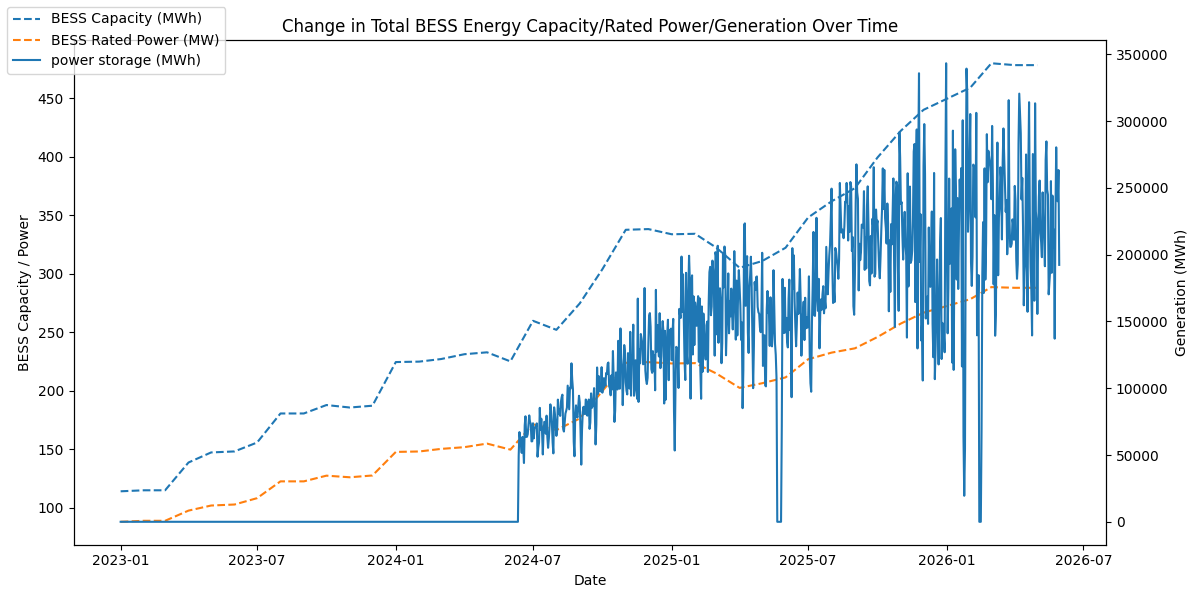

In [44]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(
    ercot_bess_monthly["month"],
    ercot_bess_monthly["total_energy_capacity_mwh"],
    label="BESS Capacity (MWh)",
    linestyle="--",
)
ax1.plot(
    ercot_bess_monthly["month"],
    ercot_bess_monthly["total_rated_power_mw"],
    label="BESS Rated Power (MW)",
    linestyle="--",
)
ax1.set_xlabel("Date")
ax1.set_ylabel("BESS Capacity / Power")
ax1.set_title("Change in Total BESS Energy Capacity/Rated Power/Generation Over Time")
ax2 = ax1.twinx()
"""
ax2.plot(
    fuel_mix_monthly.index,
    fuel_mix_monthly["coalAndLignite"],
    label="coal (MWh)",
    # color="black",
)

ax2.plot(
    fuel_mix_monthly.index,
    fuel_mix_monthly["solar"],
    label="solar (MWh)",
    #  color="yellow",
)

ax2.plot(
    fuel_mix_monthly.index,
    fuel_mix_monthly["naturalGas"],
    label="natural gas (MWh)",
    # color="yellow",
)
ax2.plot(
    fuel_mix_monthly.index,
    fuel_mix_monthly["wind"],
    label="wind (MWh)",
    # color="yellow",
)



ax2.plot(
    fuel_mix_monthly.index,
    fuel_mix_monthly["total"],
    label="total (MWh)",
    # color="yellow",
)
"""
ax2.plot(
    fuel_mix_monthly.index,
    fuel_mix_monthly["powerStorage"],
    label="power storage (MWh)",
    # color="yellow",
)

ax2.set_ylabel("Generation (MWh)")
fig.tight_layout()
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.show()